In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from array_despike import array_despike
from gaussian_fit import fit_gaussian

本文档针对Si IV看多普勒速度沿狭缝和随时间的变化

In [2]:
#选取的时间范围是21：07：22（793，396）——21：17：48（823，411）
spectrum_all=[]
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
exptime=[]
for i in range(390,412):
    rsm=fits.open(file_list[i])
    spectrum=rsm[4].data[4,:,:]
    exptime.append(rsm[0].header['EXPTIME'])
    valid_mask = (
        np.isfinite(spectrum)
        & (spectrum != -200)
    )

    spectrum_clean, info = array_despike(
        spectrum,
        sigma=8.0,
        threshold=6.0,
        itmax=20,
        no_low=False,
        valid_mask=valid_mask,
        return_info=True,
        verbose=True,
    )
    spectrum_all.append(spectrum_clean)

bright pass 0: replaced 700 pixels
bright pass 1: replaced 79 pixels
bright pass 2: replaced 11 pixels
bright pass 3: replaced 6 pixels
bright pass 4: replaced 4 pixels
bright pass 5: replaced 0 pixels
dark pass 0: replaced 8 pixels
dark pass 1: replaced 0 pixels
bright pass 0: replaced 710 pixels
bright pass 1: replaced 68 pixels
bright pass 2: replaced 6 pixels
bright pass 3: replaced 2 pixels
bright pass 4: replaced 0 pixels
dark pass 0: replaced 9 pixels
dark pass 1: replaced 0 pixels
bright pass 0: replaced 754 pixels
bright pass 1: replaced 93 pixels
bright pass 2: replaced 18 pixels
bright pass 3: replaced 11 pixels
bright pass 4: replaced 5 pixels
bright pass 5: replaced 5 pixels
bright pass 6: replaced 2 pixels
bright pass 7: replaced 1 pixels
bright pass 8: replaced 0 pixels
dark pass 0: replaced 13 pixels
dark pass 1: replaced 1 pixels
dark pass 2: replaced 0 pixels
bright pass 0: replaced 713 pixels
bright pass 1: replaced 92 pixels
bright pass 2: replaced 18 pixels
bright 

In [3]:
from datetime import datetime, timedelta

# 定义起始时间
start_time = datetime.fromisoformat('2024-06-18T16:31:42')
# 定义每次增加的时间间隔
interval = timedelta(seconds=20.8583)

# 生成时间序列
time_sequence = []
for i in range(990):
    current_time = start_time + i * interval
    # 格式化时间为只显示到秒
    time_str = current_time.strftime('%Y-%m-%dT%H:%M:%S')
    time_sequence.append(time_str)
# 打印前10个时间字符串以验证
for time_str in time_sequence[780:785]:
    print(time_str)

2024-06-18T21:02:51
2024-06-18T21:03:12
2024-06-18T21:03:33
2024-06-18T21:03:54
2024-06-18T21:04:14


In [4]:
print(spectrum.shape)

(778, 165)


In [4]:
wave_x=np.arange(rsm[4].header['CRVAL1'],rsm[4].header['CRVAL1']+rsm[4].header['CDELT1']*rsm[4].header['NAXIS1'],rsm[4].header['CDELT1'])
new_spectrum_all=[]
for i in range(len(spectrum_all)):
    spectrum1=spectrum_all[i]
    new_spectrum = np.nanmean(
        spectrum1[65:65 + 220 * 3, :].reshape(220, 3, 165),
        axis=1
    )
    new_spectrum_all.append(new_spectrum)

In [22]:
print(new_spectrum_all[0].shape)

(220, 165)


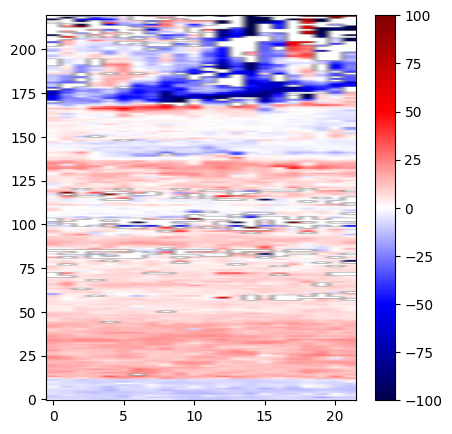

In [25]:
plt.figure(figsize=(5,5))
plt.imshow(doppler_all.T-(15.54+14.96)/2,origin='lower',aspect='auto',cmap='seismic',vmin=-100,vmax=100)
plt.colorbar()

In [15]:
#这里的谱线宽度大于0.026来自于仪器致宽和热致宽
#\sqrt{3.9**2+6.86**2}/\sqrt{2}=5.5798
#5.5798/2.997*1402.77=0.0216
doppler_all = np.zeros((len(new_spectrum_all), 220))
velocity_sigma_all = np.zeros((len(new_spectrum_all), 220))
low_snr_count = 0
invalid_sigma_count = 0

root_path = r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\all_time_fig2'
os.makedirs(root_path, exist_ok=True)

for i in range(len(new_spectrum_all)):
    folder_path = os.path.join(root_path, time_sequence[(i+ 390)* 2 + 1].replace(':', '_'))
    os.makedirs(folder_path, exist_ok=True)

    for j in range(220):
        spectrum = new_spectrum_all[i][j, :]
        wave_x1 = wave_x[70:110]
        wave_y1 = spectrum[70:110]
        wave_y1=wave_y1/exptime[i]
        result = None
        valid_fit=False
        snr=np.nan

        try:
            result = fit_gaussian(wave_x1, wave_y1, center_guess=1402.77, positive=True)

            noise = np.nanstd(np.r_[wave_y1[:8], wave_y1[-8:]])
            snr = result['amplitude'] / noise

            snr_ok = snr > 1.5
            sigma_ok = 0.0216 < result['sigma'] < 0.3

            if not snr_ok:
                low_snr_count += 1

            if not sigma_ok:
                invalid_sigma_count += 1

            valid_fit = snr_ok and sigma_ok
            doppler_all[i, j] = (result['center'] - 1402.77) / 1402.77 * 2.997e5 if valid_fit else np.nan
            velocity_sigma_all[i, j] = result['sigma']/ 1402.77 * 2.997e5 if valid_fit else np.nan

        except Exception as error:
            doppler_all[i, j] = np.nan
            print(f"拟合失败：i={i}, j={j}, {error}")

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.scatter(wave_x1, wave_y1, c='red', label='Spectrum')

        if  valid_fit:
            ax.plot(result['x'], result['yfit'], c='blue', label='Gaussian fit')
            ax.text(0.05, 0.95, f'doppler velocity: {doppler_all[i,j]:.4f} km/s \n sigma: {velocity_sigma_all[i,j]:.4f} km/s', 
                    transform=ax.transAxes, fontsize=10, verticalalignment='top')
            ax.set_title(f'i={i}, j={j}, SNR={snr:.2f}, sigma={result["sigma"]:.4f}')
        else:
            ax.set_title(f'Fit failed: i={i}, j={j}')

        ax.axvline(x=1402.77, linestyle='--', color='black', label='Reference')
        ax.set_ylabel('Intensity [DN s$^{-1}$]')
        ax.grid()
        ax.legend()

        save_path = os.path.join(folder_path, f'{j}.png')
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close(fig)

nan_count = np.isnan(doppler_all).sum()
print("NaN count:", nan_count)
print("Low SNR count:", low_snr_count)
print("Invalid sigma count:", invalid_sigma_count)

c:\Users\xiao\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\optimize\_lsq\common.py:115: RuntimeWarning: divide by zero encountered in divide
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm


NaN count: 507
Low SNR count: 136
Invalid sigma count: 441


In [17]:
np.save(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\doppler_all.npy',doppler_all)
np.save(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\velocity_sigma_all.npy',velocity_sigma_all)

In [18]:
solar_xy=readsav(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\solar_xy.sav')
print(solar_xy.keys())
solar_x=solar_xy['solar_x']
solar_y=solar_xy['solar_y']
all_sji_image=readsav(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\all_sji_image.sav')['matrix_struct']


dict_keys(['solar_x', 'solar_y'])


In [19]:
time_x=time_sequence[781:825:2]
time_xx=[dt[-8:] for dt in time_x]
print(time_xx)

['21:03:12', '21:03:54', '21:04:35', '21:05:17', '21:05:59', '21:06:40', '21:07:22', '21:08:04', '21:08:46', '21:09:27', '21:10:09', '21:10:51', '21:11:32', '21:12:14', '21:12:56', '21:13:38', '21:14:19', '21:15:01', '21:15:43', '21:16:24', '21:17:06', '21:17:48']


Text(0.5, 1.0, 'Si IV Velocity Sigma')

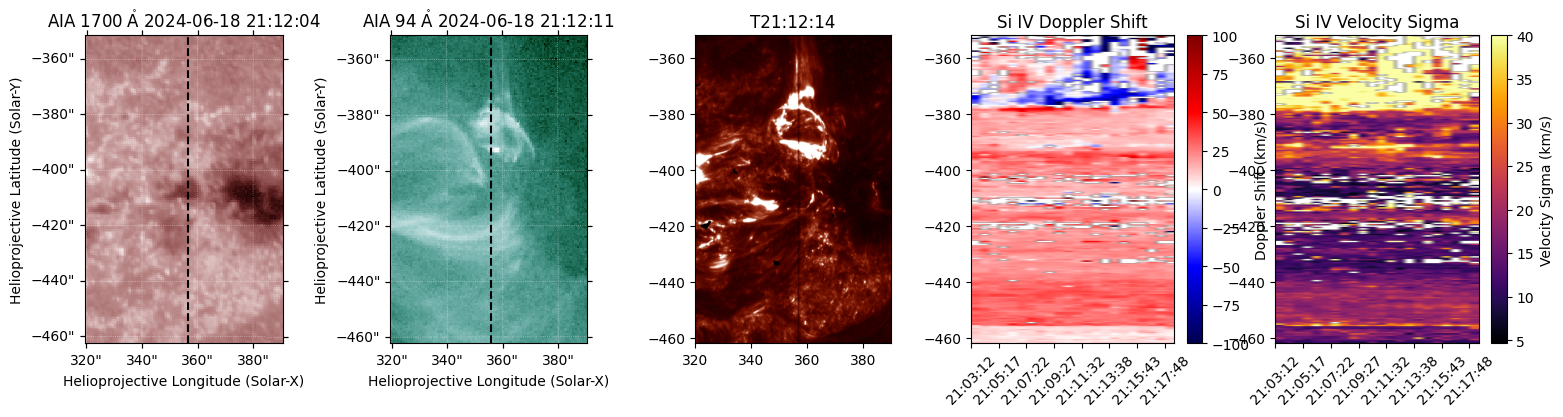

In [23]:
fig=plt.figure(figsize=(19,4))
gs=gridspec.GridSpec(1,5)

aia1700=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\1700\aia.lev1_uv_24s.2024-06-18T211205Z.1700.image_lev1.fits')
bottom_left=SkyCoord(320*u.arcsec,(-407-332*0.166)*u.arcsec,frame=aia1700.coordinate_frame)
top_right=SkyCoord((320+422*0.166)*u.arcsec,(-407+332*0.166)*u.arcsec,frame=aia1700.coordinate_frame)
aia1700_sub=aia1700.submap(bottom_left=bottom_left, top_right=top_right)
ax0=fig.add_subplot(gs[0],projection=aia1700_sub)
image = aia1700_sub.plot(axes=ax0)
coord = SkyCoord(
    solar_x[4, 0] * u.arcsec,
    0 * u.arcsec,
    frame=aia1700_sub.coordinate_frame
)

x_pixel, _ = aia1700_sub.world_to_pixel(coord)
ax0.axvline(x=x_pixel.value, color="black", linestyle="--")

aia94=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\.94\aia.lev1_euv_12s.2024-06-18T211213Z.94.image_lev1.fits')
bottom_left=SkyCoord(320*u.arcsec,(-407-332*0.166)*u.arcsec,frame=aia94.coordinate_frame)
top_right=SkyCoord((320+422*0.166)*u.arcsec,(-407+332*0.166)*u.arcsec,frame=aia94.coordinate_frame)
aia94_sub=aia94.submap(bottom_left=bottom_left, top_right=top_right)
ax1=fig.add_subplot(gs[1],projection=aia94_sub)
image = aia94_sub.plot(axes=ax1)
ax1.axvline(x=x_pixel.value, color="black", linestyle="--")

ax2=fig.add_subplot(gs[2])
ax2.imshow(all_sji_image[807][0][:,:],cmap='irissji1400',vmin=0,vmax=20,origin='lower',
	extent=[320,320+422*0.166,-407-332*0.166,-407+332*0.166])
ax2.set_title('T21:12:14')
ax3=fig.add_subplot(gs[3])

ax3.imshow(doppler_all.T,cmap='seismic',vmin=-100,vmax=100,origin='lower',
           aspect='auto',extent=[0,22,-407-332*0.166,-407+332*0.166])
cbar=ax3.figure.colorbar(ax3.images[0],ax=ax3)
cbar.set_label('Doppler Shift (km/s)')
ax3.set_xticks(range(0, 22, 3))
ax3.set_xticklabels(time_xx[::3],rotation=45)
ax3.set_title('Si IV Doppler Shift')

ax4=fig.add_subplot(gs[4])
ax4.imshow(velocity_sigma_all.T,cmap='inferno',vmax=40,origin='lower',
           aspect='auto',extent=[0,22,-407-332*0.166,-407+332*0.166])
cbar2=ax4.figure.colorbar(ax4.images[0],ax=ax4)
cbar2.set_label('Velocity Sigma (km/s)')
ax4.set_xticks(range(0, 22, 3))
ax4.set_xticklabels(time_xx[::3],rotation=45)
ax4.set_title('Si IV Velocity Sigma')

Text(0.5, 1.0, 'Si IV Doppler Shift')

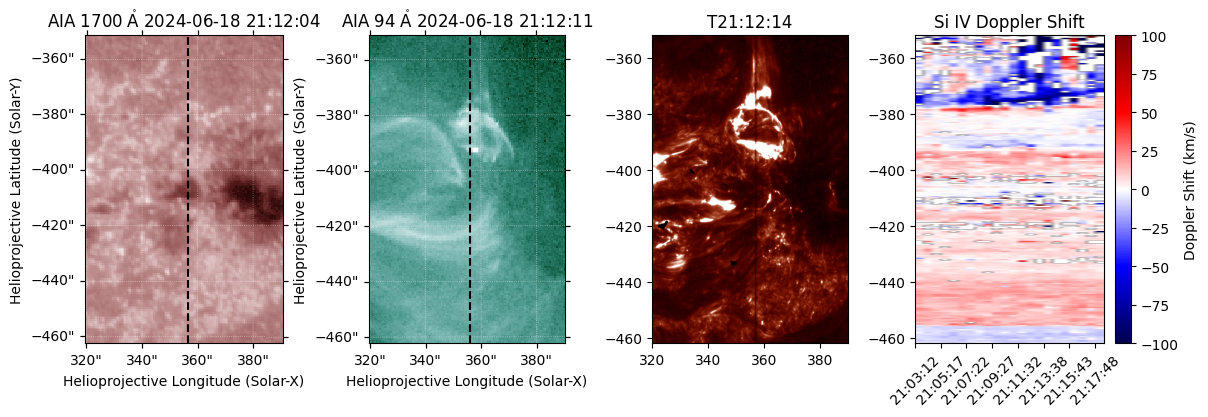

In [26]:
fig=plt.figure(figsize=(14,4))
gs=gridspec.GridSpec(1,4)

aia1700=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\1700\aia.lev1_uv_24s.2024-06-18T211205Z.1700.image_lev1.fits')
bottom_left=SkyCoord(320*u.arcsec,(-407-332*0.166)*u.arcsec,frame=aia1700.coordinate_frame)
top_right=SkyCoord((320+422*0.166)*u.arcsec,(-407+332*0.166)*u.arcsec,frame=aia1700.coordinate_frame)
aia1700_sub=aia1700.submap(bottom_left=bottom_left, top_right=top_right)
ax0=fig.add_subplot(gs[0],projection=aia1700_sub)
image = aia1700_sub.plot(axes=ax0)
coord = SkyCoord(
    solar_x[4, 0] * u.arcsec,
    0 * u.arcsec,
    frame=aia1700_sub.coordinate_frame
)

x_pixel, _ = aia1700_sub.world_to_pixel(coord)
ax0.axvline(x=x_pixel.value, color="black", linestyle="--")

aia94=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\.94\aia.lev1_euv_12s.2024-06-18T211213Z.94.image_lev1.fits')
bottom_left=SkyCoord(320*u.arcsec,(-407-332*0.166)*u.arcsec,frame=aia94.coordinate_frame)
top_right=SkyCoord((320+422*0.166)*u.arcsec,(-407+332*0.166)*u.arcsec,frame=aia94.coordinate_frame)
aia94_sub=aia94.submap(bottom_left=bottom_left, top_right=top_right)
ax1=fig.add_subplot(gs[1],projection=aia94_sub)
image = aia94_sub.plot(axes=ax1)
ax1.axvline(x=x_pixel.value, color="black", linestyle="--")

ax2=fig.add_subplot(gs[2])
ax2.imshow(all_sji_image[807][0][:,:],cmap='irissji1400',vmin=0,vmax=20,origin='lower',
	extent=[320,320+422*0.166,-407-332*0.166,-407+332*0.166])
ax2.set_title('T21:12:14')
ax3=fig.add_subplot(gs[3])

# ax3.imshow(doppler_all.T,cmap='seismic',vmin=-100,vmax=100,origin='lower',
#            aspect='auto',extent=[0,22,-407-332*0.166,-407+332*0.166])
ax3.imshow(doppler_all.T-(15.54+14.96)/2,cmap='seismic',vmin=-100,vmax=100,origin='lower',
           aspect='auto',extent=[0,22,-407-332*0.166,-407+332*0.166])
cbar=ax3.figure.colorbar(ax3.images[0],ax=ax3)
cbar.set_label('Doppler Shift (km/s)')
ax3.set_xticks(range(0, 22, 3))
ax3.set_xticklabels(time_xx[::3],rotation=45)
ax3.set_title('Si IV Doppler Shift')

In [34]:
np.save(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\doppler_all_corrected.npy',doppler_all)

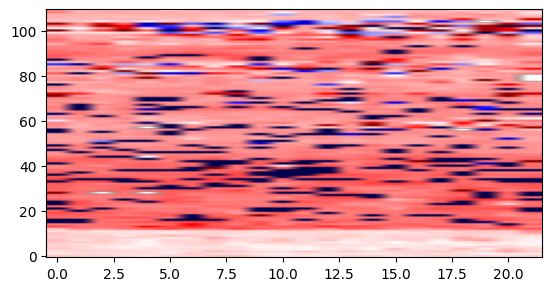

In [9]:
plt.imshow(doppler_all.T,cmap='seismic',vmin=-100,vmax=100,origin='lower',
           aspect=0.1)